# Visión Computacional

## Jesús Virgilio Ayala Gaspar

---

## ADA 01 - Corrección de Iluminación

Utilizando operaciones básicas entre imagenes implemente un programa que asegure que la iluminación sea uniforme. Para este caso asumimos que la varíación en iluminación en una imágen se puede modelar aditivamente, esto es:

$I = I_s + P_i$

donde $I$ es la imagen que vamos a procesar, $I_s$ es una imagen sin iluminación o bien uniformemente iluminada y $P_i$ es un plano de iluminación. 

---

### Ajustar un plano a la imagen. 

#### Regresión Lineal

Un plano lo representamos con la siguiente ecuación:

$Ax + By + Cz + D = 0$

donde $[A,\, B,\, C]$ son los componente de un vector normal a la superficie del plano y $D$ es la distancia del plano al origen del sistema.

Para nuestro problema, nosotros extraeremos los valores $x$, $y$, y $z$ de la imagen, siendo $x$ y $y$ el conjunto de coordenadas de cada pixel, y $z$ el valor de la imagen que corresponde a las coordenadas $(x,y)$.

#### Muestreo Regular

Para nuestro problema no requerimos utilizar todos los pixeles de la imagen, sino solo un subconjunto de ellos. Si queremos por ejemplo muestrar 100 valores de la imagen podemos hacer la siguiente:

In [1]:
import numpy as np
import cv2

def regSampling(col, ren, I):
    x = np.floor(np.linspace(0,col-1,10)).astype(np.int16)
    y = np.floor(np.linspace(0,ren-1,10)).astype(np.int16)
    
    X, Y = np.meshgrid(x,y)
    X = X.flatten()
    Y = Y.flatten()
    Z = I[Y, X]
                 
    output = [X, Y, Z]
                 
    return output

---
#### Muestreo Aleatorio

De igual manera, si tenemos una imagen I con ren renglones y col columnas, podemos definir los valores de $(x,y,z)$ como sigue:

In [2]:
import numpy as np
import cv2

def randSampling(col, ren, I):
    x = np.floor((col-1) * np.random.rand(10)).astype(np.int16)
    y = np.floor((ren-1) * np.random.rand(10)).astype(np.int16)
    
    X, Y = np.meshgrid(x,y)
    X = X.flatten()
    Y = Y.flatten()
    
    #Línea de código original
    #Z = I[X,Y]
    
    #Línea de código corregida que permite que el programa funcione
    Z = I[Y, X]
    
    output = [X, Y, Z]
    
    return output

---
#### Ajustar el plano.

Ya que tenemos los datos de la imagen codificados como tripletas $[x,y,z]$, lo que sigue es encontrar

los parámetros $[A,B,C,D]$ del plano $Ax + By + Cz + D = 0$. En clase comentamos que eso se puede construir un sistema lineal como el siguiente:

$M⋅x = b$

donde:

$M = [x,\,y,\,1]$

$b = −z$

y $\mathbf{x}$, $\mathbf{y}$, $\mathbf{z}$ son vectores columna que contienen los datos de la imagen.

En clase comentamos que una aproximación óptima bajo un criterio de mínimos cuadrados se puede obtener con la siguiente fórmula:

$x = (M ⋅ M^{T})^{-1} ⋅ M^{T}b$

En la práctica el problema no es tan simple, por consideraciónes numéricas, por lo que utilizaremos la rutina fitPlane proporcionada por el maestro:

In [3]:
import numpy as np

from sklearn import linear_model

def fitPlane(x, y, z):
        n=len(x)
        if n != len(y) or n != len(z):
                print('ERROR')
                return

        X_data =np.hstack([x.reshape((-1,1)),y.reshape((-1,1))])

        Y_data = z

        reg = linear_model.LinearRegression().fit(X_data, Y_data)

        Sol = [reg.coef_[0],reg.coef_[1], 1, reg.intercept_]
        return Sol

---
#### Corregir la imagen

La última etapa del metodo es generar una matriz que tenga las mismas dimensiones que la imagen original, en donde se evalue la formula del plano, esto es:

$$
P[i,j] = \frac{-A x[i,j] + C y[i,j] + D}{Z[i,j]}, \quad i \in [0, col-1], \quad j \in [0, ren-1]
$$

donde $ren$ y $col$ son el número de renglones y columnas de la imagen.

Ya que se obtiene este plano $P$, debemos restarlo a la imágen original y normalizar la salida.

In [4]:
import numpy as np
import cv2

def correction(A, B, C, D, I):
    ren, col = I.shape
    
    #Obtención de P_i
    X_full, Y_full = np.meshgrid(np.arange(col), np.arange(ren))
    P = A * X_full + B * Y_full + D

    #Corrección del tipo de dato
    I = I.astype(np.float32)
    
    #Imágen Corregida
    Ic = I - P 
    
    #Normalización de la imágen
    Ic = cv2.normalize(Ic, None, 0, 255, cv2.NORM_MINMAX)
    Ic = Ic.astype(np.uint8)
    
    return Ic

---
### Ejecución

Una vez definidas las funciones que vamos a utilizar, creamos el bloque de código principal donde se ejecutará la corrección de iluminación

Para ello nos fueron proporcionadas 3 variaciones de una imágen que cuentan con diferentes niveles de iluminación lo cuál deberemos corregir:

Ejemplo 1:
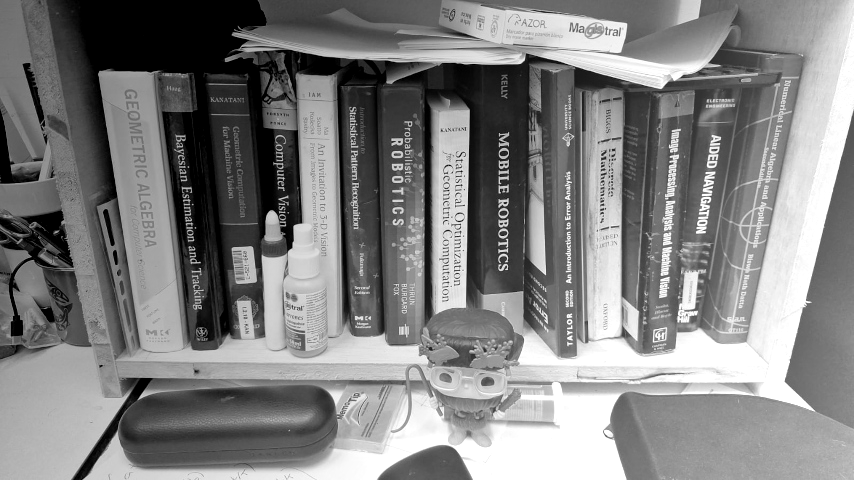


De igual manera, por alguna razón jupyter no me permite agregar la imágen 2 y 3 y por eso no se encuentran en la versioń original

Ejemplo 2:
![Libros2.png](attachment:Libros2.png)

Ejemplo 3:
![Libros3.png](attachment:Libros3.png)


In [5]:
import numpy as np
import cv2

Io = cv2.imread('Libros1.png', cv2.IMREAD_GRAYSCALE) #Imagen original

#Creación de una ventana con la imágen original
cv2.namedWindow('Imagen Original', cv2.WINDOW_NORMAL)
cv2.imshow('Imagen Original', Io)

#Obtención del numero de filas y columnas (en pixéles) de la Imágen Original
ren, col = Io.shape

#Aplicación del Muestreo Regular
X, Y, Z = randSampling(col, ren, Io)

#Ajuste del plano a la imágen
A, B, C, D = fitPlane(X, Y, Z)

#Corrección de iluminación de la imágen
Ic = correction(A, B, C, D, Io)

cv2.namedWindow('Imagen Corregida', cv2.WINDOW_NORMAL)
cv2.imshow('Imagen Corregida', Ic)

cv2.waitKey(0)
cv2.destroyAllWindows()

QSocketNotifier: Can only be used with threads started with QThread
